# GOES ABI True Color — executed example

## Goal

Download the official Satpy GOES ABI demonstration dataset, enter a geographic
domain in decimal longitude/latitude, create a True Color composite, save it,
and display the exact generated image inside this notebook.

The saved output below is produced by these cells, not by an external image.

## Setup

Install the notebook environment once from the repository root:

```bash
python -m pip install -r requirements-notebooks.txt
```

The first execution downloads approximately 110 MB of public GOES demo data.
Later executions reuse the local files.

In [1]:
from pathlib import Path
import sys

from IPython.display import Image, display
from PIL import Image as PillowImage
from satpy import Scene
from satpy.demo.abi_l1b import get_us_midlatitude_cyclone_abi

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from examples.render_satellite import crop_and_resample_scene, validate_bbox

## Steps

### 1. Enter the decimal domain

The order is `MIN_LON, MIN_LAT, MAX_LON, MAX_LAT`. All four values are written
as decimal degrees, including `.0` for whole degrees.

In [2]:
DEMO_DATA_DIR = REPO_ROOT / "data" / "demo-goes"
DOMAIN = (-102.0, 25.0, -84.0, 38.0)
COMPOSITE = "true_color"
OUTPUT = REPO_ROOT / "output" / "notebook_goes_demo_true_color.png"

validate_bbox(DOMAIN)

(-102.0, 25.0, -84.0, 38.0)

### 2. Download the official demo files

Satpy downloads the public GOES-16 CONUS dataset and returns every ABI channel.
The selected domain intersects this source coverage.

In [3]:
files = get_us_midlatitude_cyclone_abi(base_dir=str(DEMO_DATA_DIR))
print(f"GOES files: {len(files)}")
print(Path(files[0]).name)

GOES files: 16
OR_ABI-L1b-RadC-M3C01_G16_s20190730002190_e20190730004563_c20190730005006.nc


### 3. Load the True Color composite

In [4]:
scene = Scene(reader="abi_l1b", filenames=files)
available = {str(name) for name in scene.available_composite_names()}

selected_composite = COMPOSITE
if selected_composite not in available and "true_color_raw" in available:
    selected_composite = "true_color_raw"
if selected_composite not in available:
    raise ValueError("The demo files cannot create a True Color composite.")

scene.load([selected_composite], generate=True)
print(f"Loaded composite: {selected_composite}")

No sensor name specified in HDF5 file


The following datasets were not created and may require resampling to be generated: DataID(name='true_color')


Loaded composite: true_color


### 4. Crop, resample, and save

In [5]:
output_scene = crop_and_resample_scene(scene, domain=DOMAIN)
OUTPUT.parent.mkdir(parents=True, exist_ok=True)
output_scene.save_dataset(
    selected_composite,
    filename=str(OUTPUT),
    writer="simple_image",
)

# Keep the embedded result small enough for reliable GitHub rendering.
with PillowImage.open(OUTPUT) as image:
    image.thumbnail((1400, 1000))
    image.save(OUTPUT, optimize=True)

print(f"Image created: {OUTPUT.resolve()}")

No sensor name specified in HDF5 file


Image created: /Users/rmsm1/Documents/Codex/2026-07-23/github-plugin-github-openai-curated-remote-5/GOES-VIIRS-Imagery-Guide/output/notebook_goes_demo_true_color.png


### 5. Display the exact generated result

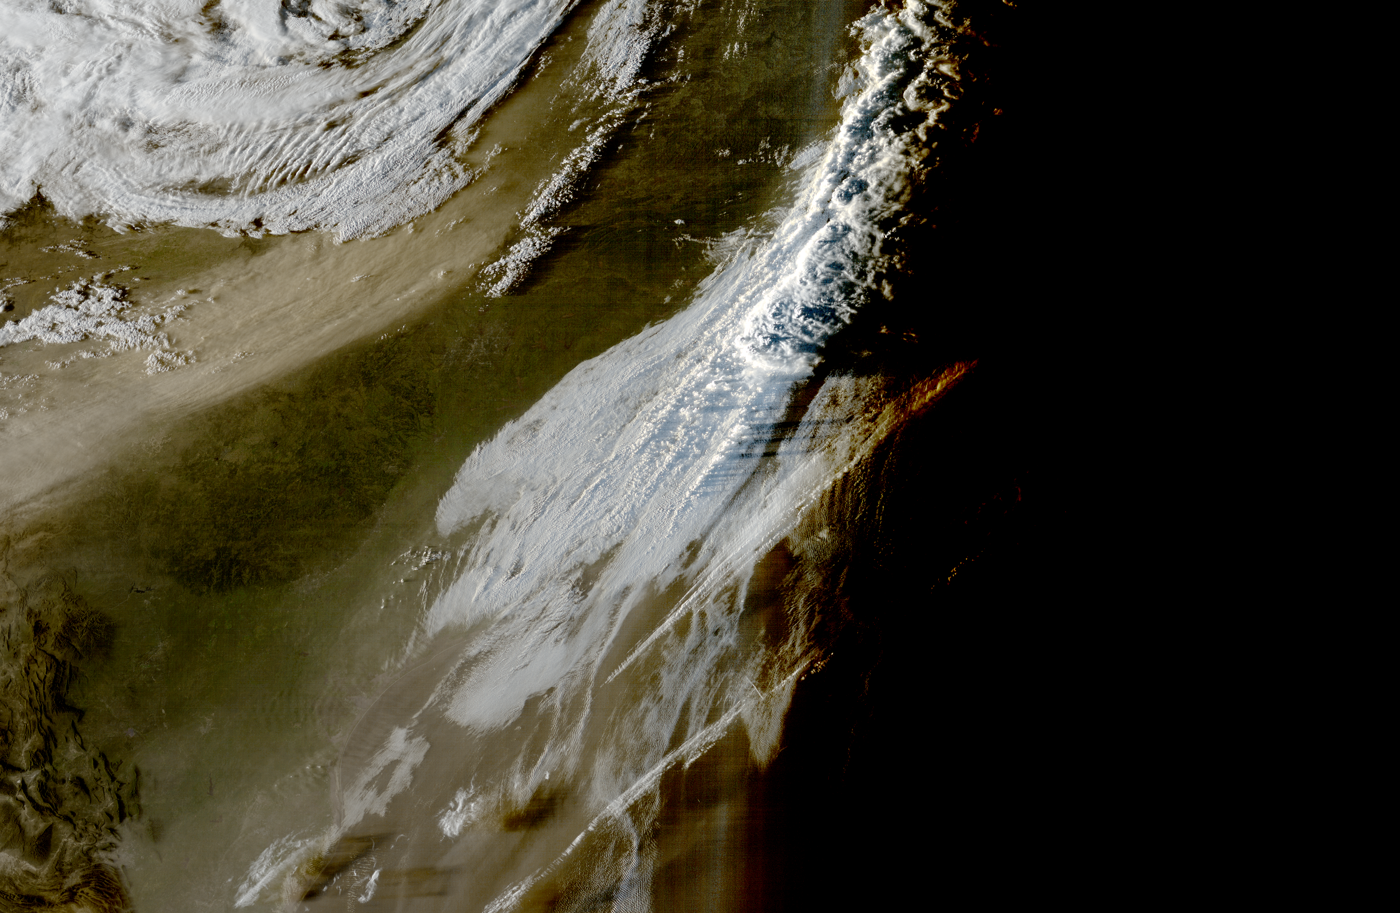

In [6]:
display(Image(filename=str(OUTPUT)))

## Checks

Confirm that the saved PNG exists and has nonzero dimensions.

In [7]:
if not OUTPUT.exists():
    raise FileNotFoundError(OUTPUT)

with PillowImage.open(OUTPUT) as image:
    print(f"PNG size: {image.width} x {image.height} pixels")
    assert image.width > 0 and image.height > 0

PNG size: 1400 x 913 pixels


## Next steps — use Shishaldin

The executed result above uses the official CONUS demo, so its domain is not
Shishaldin. To process Shishaldin, download GOES Full Disk (`F`) channels from
the same scan, replace `files` with those paths, and enter:

```python
DOMAIN = (-166.0, 54.0, -162.0, 56.0)
```

Adjust every decimal value for the exact study area. No geographic preset is
selected automatically.

Source: [Satpy demo data documentation](https://satpy.readthedocs.io/en/stable/api/satpy.demo.html).